In [1]:
### from Maria Molina 2025
import xarray as xr 
import cartopy.crs as ccrs 
import numpy as np
import matplotlib.pyplot as plt 
import xesmf as xe 

model_version = 'MD-1p5'

era5_regridded = xr.open_dataset("/glade/work/khall/ERA5/AIMIP-Data/era5-flat-1p5x1p5.nc").da.sel(time=slice("1978-10-01", None))
ds_0k = xr.open_mfdataset(f'/glade/work/khall/monthly-diffusion/scripts/observed_forcings-{model_version}/*').da
ds_2k = xr.open_mfdataset(f'/glade/work/khall/monthly-diffusion/scripts/p2k_forcings-{model_version}/*').da
ds_4k = xr.open_mfdataset(f'/glade/work/khall/monthly-diffusion/scripts/p4k_forcings-{model_version}/*').da

START


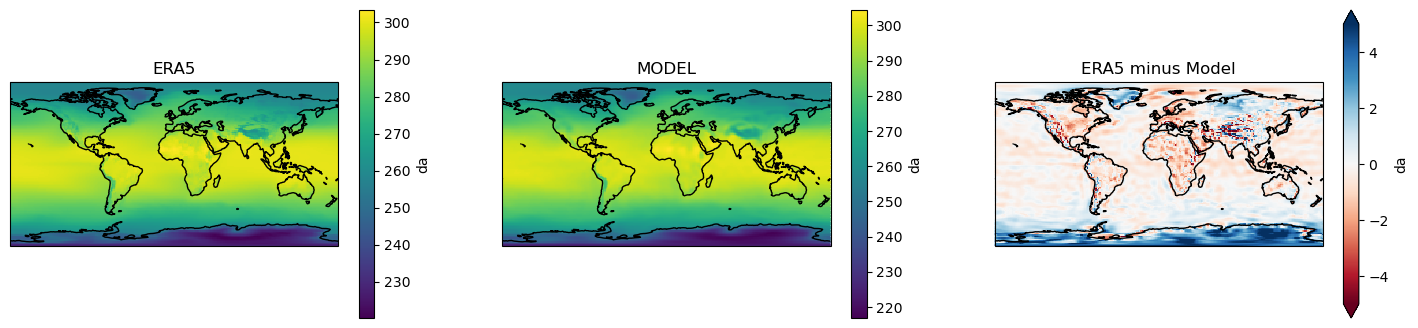

FUTURE


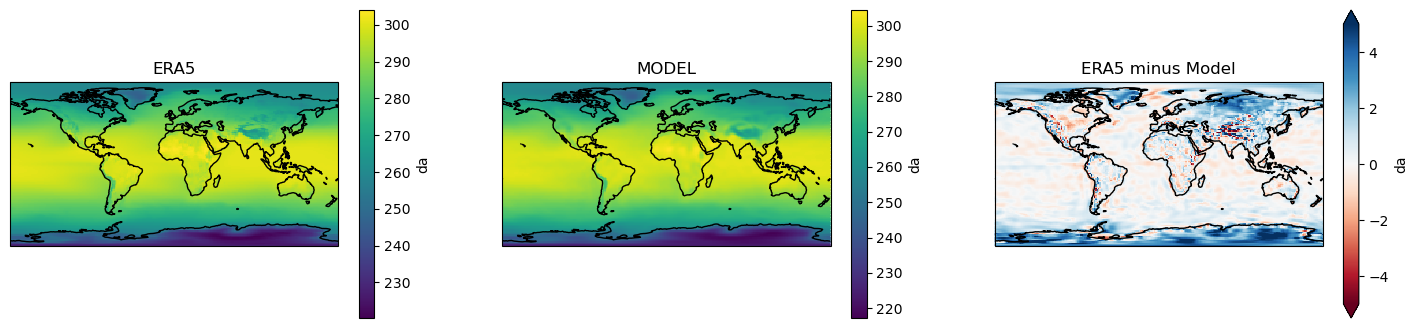

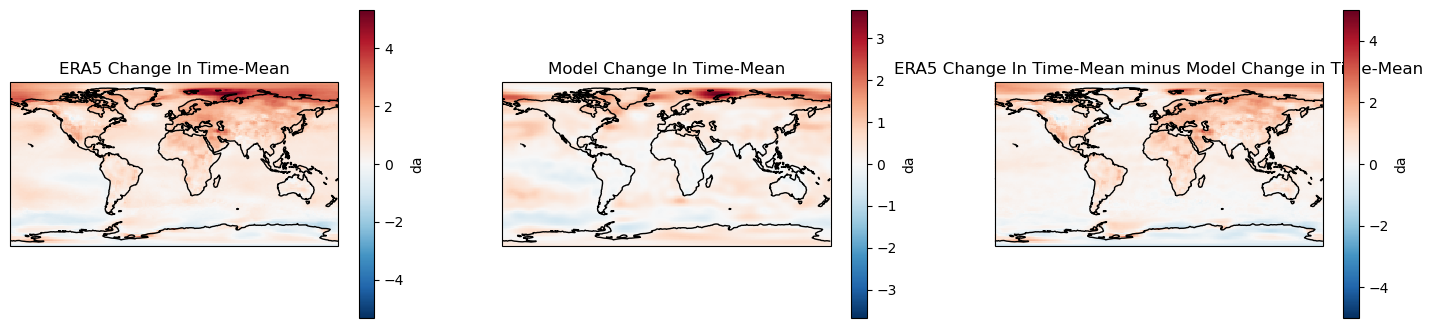

In [2]:

era5var = 'VAR_2TSFC'
ds_0k_regridded = ds_0k.sel(varlev=era5var).mean('member')
ds_2k_regridded = ds_2k.sel(varlev=era5var).mean('member')
ds_4k_regridded = ds_4k.sel(varlev=era5var).mean('member')


print('START')
era5_var_start = era5_regridded.sel(varlev=era5var, time=slice("1978-10-01", "1988-12-31"))
model_var_start = ds_0k_regridded.sel(time=slice("1978-10-01", "1988-12-31"))

rmse_start = era5_var_start.mean('time') - model_var_start.mean('time')

fig, axs = plt.subplots(nrows=1, ncols=3, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(18,4)) 
era5_var_start.mean('time').plot(ax=axs[0])
axs[0].set_title('ERA5') 

model_var_start.mean('time').plot(ax=axs[1]) 
axs[1].set_title('MODEL') 

rmse_start.plot(ax=axs[2], vmin=-5, vmax=5, cmap='RdBu')
axs[2].set_title('ERA5 minus Model') 

for ax in axs:
    ax.coastlines()
plt.show()



####### future
print('FUTURE')
era5_var_end = era5_regridded.sel(varlev=era5var, time=slice("2012-01-01", None))
model_var_end = ds_0k_regridded.sel(time=slice("2012-01-01", "2022-12-31"))


#rmse2 = np.sqrt( (era5_var.mean('time') - model_var.mean('time'))**2 )
rmse_end = era5_var_end.mean('time') - model_var_end.mean('time')

fig, axs = plt.subplots(nrows=1, ncols=3, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(18,4)) 
era5_var_end.mean('time').plot(ax=axs[0])
axs[0].set_title('ERA5') 

model_var_end.mean('time').plot(ax=axs[1]) 
axs[1].set_title('MODEL') 

rmse_end.plot(ax=axs[2], vmin=-5, vmax=5, cmap='RdBu')
axs[2].set_title('ERA5 minus Model') 

for ax in axs:
    ax.coastlines()
plt.show()

fig, ax = plt.subplots(nrows=1, ncols=3, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(18,4)) 
pl = (era5_var_end.mean('time') - era5_var_start.mean('time')).plot(ax = ax[0],  cmap='RdBu_r') 
ax[0].coastlines() 
t = ax[0].set_title('ERA5 Change In Time-Mean') 

pl = (model_var_end.mean('time') - model_var_start.mean('time')).plot(ax = ax[1], cmap='RdBu_r') 
ax[1].coastlines() 
t = ax[1].set_title('Model Change In Time-Mean') 

pl = ((era5_var_end.mean('time') - era5_var_start.mean('time')) - (model_var_end.mean('time') - model_var_start.mean('time'))).plot(ax = ax[2], vmin=-5, vmax = 5, cmap='RdBu_r') 
ax[2].coastlines() 
t = ax[2].set_title('ERA5 Change In Time-Mean minus Model Change in Time-Mean') 

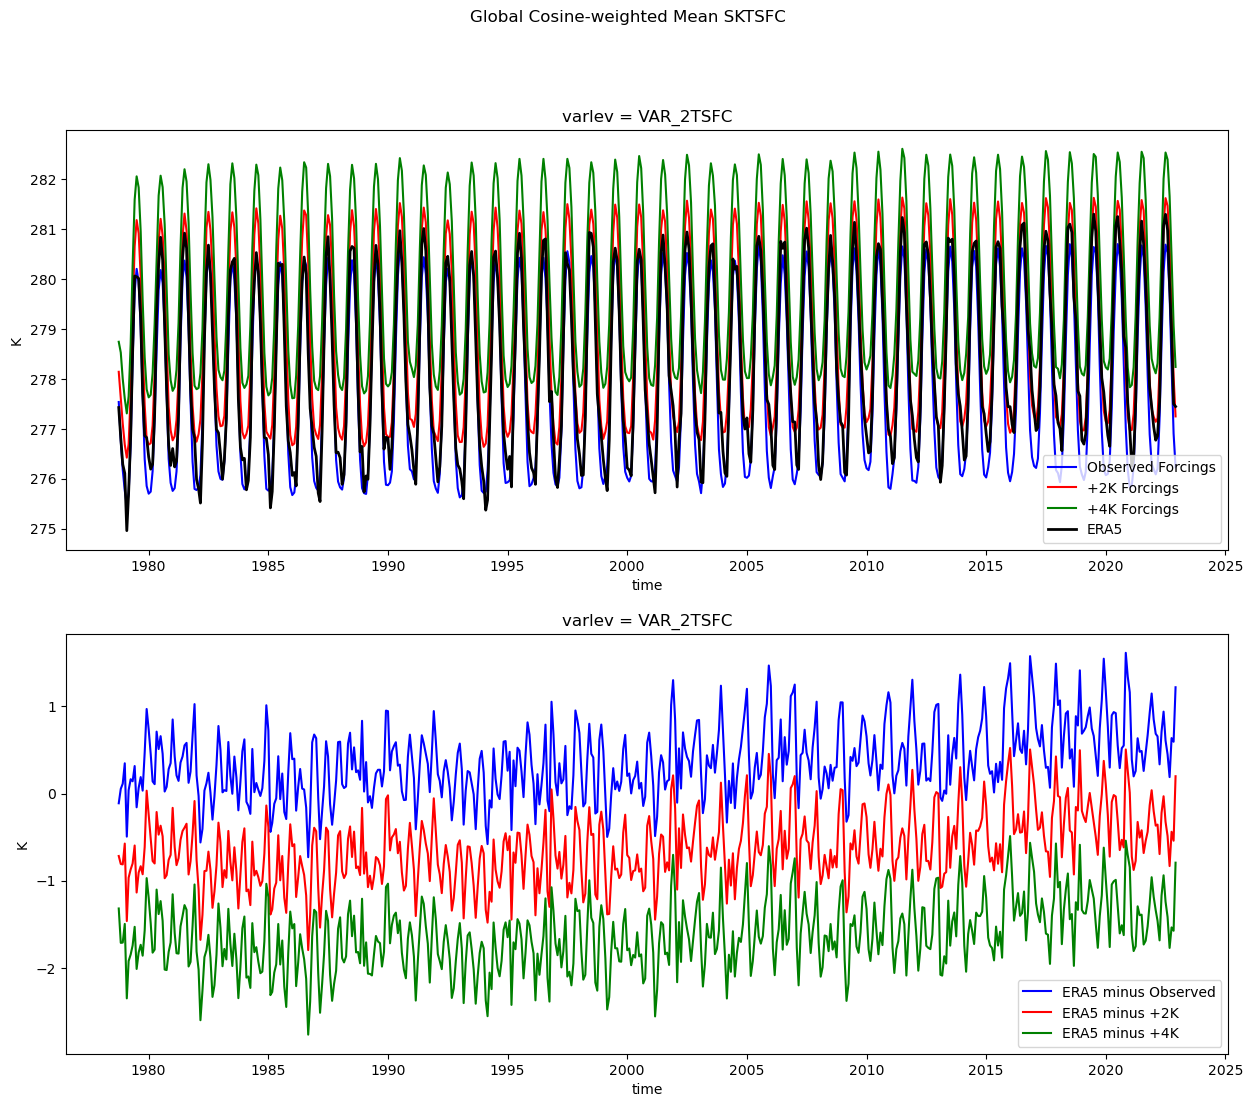

In [3]:
era5_var = era5_regridded.sel(varlev=era5var, time=slice("1978-01-01", "2022-12-31"))
model_var_0k = ds_0k_regridded.sel(time=slice("1978-01-01", "2022-12-31")).assign_coords({'time': era5_var.time})
model_var_2k = ds_2k_regridded.sel(time=slice("1978-01-01", "2022-12-31")).assign_coords({'time': era5_var.time})
model_var_4k = ds_4k_regridded.sel(time=slice("1978-01-01", "2022-12-31")).assign_coords({'time': era5_var.time})

units = "K"


era5_clwgm = era5_var.mean(['lat', 'lon'])


model_era5_clwgm_0k = model_var_0k.mean(['lat', 'lon'])
model_era5_clwgm_2k = model_var_2k.mean(['lat', 'lon'])
model_era5_clwgm_4k = model_var_4k.mean(['lat', 'lon'])


fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(15, 12))
model_era5_clwgm_0k.plot.line(ax=ax[0], x='time', color='blue',  label='Observed Forcings')
model_era5_clwgm_2k.plot.line(ax=ax[0], x='time', color='red',  label='+2K Forcings')
model_era5_clwgm_4k.plot.line(ax=ax[0], x='time', color='green',  label='+4K Forcings')

era5_clwgm.plot(ax=ax[0], x='time', label='ERA5', color='black', linewidth=2)
ax[0].set_ylabel(f"{units}")
ax[0].legend() 

(era5_clwgm - model_era5_clwgm_0k.sel(time=era5_clwgm.time)).plot.line(ax=ax[1], color='blue',  x='time', label = "ERA5 minus Observed")
(era5_clwgm - model_era5_clwgm_2k.sel(time=era5_clwgm.time)).plot.line(ax=ax[1], color='red',  x='time', label = "ERA5 minus +2K")
(era5_clwgm - model_era5_clwgm_4k.sel(time=era5_clwgm.time)).plot.line(ax=ax[1], color='green',  x='time', label = "ERA5 minus +4K")

ax[1].legend() 
ax[1].set_ylabel(f"{units}")

plt.suptitle(f"Global Cosine-weighted Mean SKTSFC")
plt.show()


In [4]:
import pandas as pd 

def global_detrend(da, time_dim='time', spatial_dims=['lat', 'lon'], deg=2, p=None):
    if p is not None:
        return da - xr.polyval(da['time'],  p.polyfit_coefficients), None, None, p
    else:
        # detrend along a single dimension
        weights = np.cos(np.deg2rad(da.lat))
        weights.name = "weights"

        # Apply the weights and compute the mean across lat/lon
        da_weighted = da.weighted(weights)
        weighted_mean = da_weighted.mean(dim=spatial_dims)
        p = weighted_mean.polyfit(dim=time_dim, deg=deg)
        fit = xr.polyval(da[time_dim], p.polyfit_coefficients)
        return da - fit, fit, weighted_mean, p #.polyfit_coefficient


def detrend(da, dim='time', deg=2):
    # detrend along a single dimension
    # below assumes monthly data, returns trend in per-year
    da = da.assign_coords({dim: [i/12 for i in range(da.coords[dim].values.shape[0])]})
    p = da.polyfit(dim=dim, deg=deg)
    fit = xr.polyval(da[dim], p.polyfit_coefficients)
    return da - fit, p.polyfit_coefficients.sel(degree=1), p

def remove_climo(monthly, dim='time', sub=None, monthly_climatology=None):
    if monthly_climatology is None:
        if sub is not None: 
            monthly_climatology = monthly.sel({dim:sub}).groupby(f'{dim}.month').mean()
        else:
            monthly_climatology = monthly.groupby(f'{dim}.month').mean()
    
    toconcat = []
    for year in sorted(list(set( [ pd.Timestamp(i).year for i in monthly.coords[dim].values] ))):
        ds_yearly = monthly.sel(time=slice(pd.Timestamp(year, 1, 1), pd.Timestamp(year, 12,31))).groupby(f'{dim}.month').mean() - monthly_climatology
        ds_yearly = ds_yearly.assign_coords({'month': [ pd.Timestamp(year, j, 1) for j in ds_yearly.coords['month'].values ] } ).rename({'month': dim})
        toconcat.append(ds_yearly)
    monthly_anom = xr.concat(toconcat, dim).sortby(dim)
    return monthly_anom, monthly_climatology



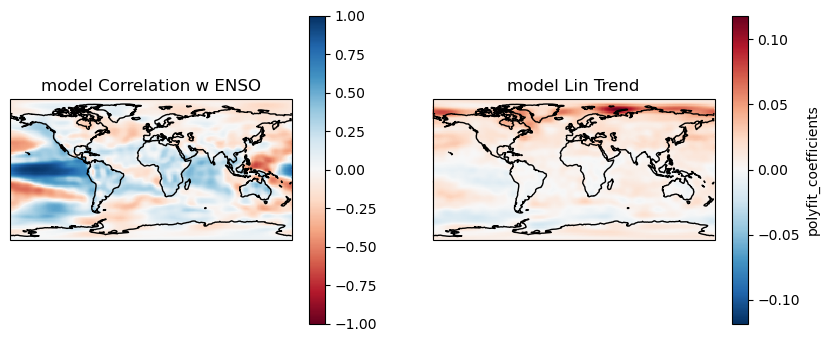

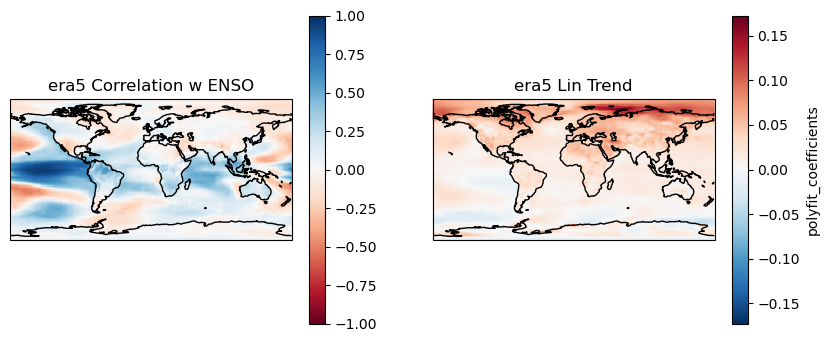

In [5]:
forcings = xr.open_dataset('/glade/work/khall/ERA5/AIMIP-Data/aimip-forcings-flat-1p5x1p5.nc')
enso = forcings.sel(varlev='SSTKSFC').da
enso, fit, gwm, p = global_detrend(enso, deg=2) 
enso, mc = remove_climo(enso) 
enso = enso.sel(lat=slice(-5,5), lon=slice(190, 240)).mean(['lat', 'lon'])

titles = ['model', 'era5']
for _, da in enumerate([model_var_0k, era5_var]):
    da_dt, fit, gwm, p5  = global_detrend(da, deg=2)
    da_dt, monthly_clim = remove_climo(da_dt)

    corr = xr.corr(enso, da_dt, dim='time')
    da2, trend, p5  = detrend(da, deg=1)

    fig, ax = plt.subplots(ncols=2, nrows=1, subplot_kw={'projection': ccrs.PlateCarree()}, figsize = (10, 4) )
    pl = corr.plot(ax=ax[0], vmin=-1, vmax=1, cmap='RdBu')
    ax[0].coastlines() 
    ax[0].set_title(f'{titles[_]} Correlation w ENSO')


    trend.plot(ax=ax[1],  cmap='RdBu_r')
    ax[1].coastlines() 
    ax[1].set_title(f'{titles[_]} Lin Trend')




In [6]:
def calc_nao(slp):
    # --- Convert to hPa if necessary ---
    if slp.max() > 2000:   # ERA5 is in Pa
        slp = slp / 100.0  # convert Pa → hPa

    # --- Select NAO reference locations ---
    # Iceland Low ~ (65N, 20W)
    # Azores High ~ (35N, 20W)
    # Use .sel(method="nearest") to sample data at given coordinates
    slp_iceland = slp.sel(lat=65, lon=340, method="nearest")   # 340°E = 20°W
    slp_azores  = slp.sel(lat=35, lon=340, method="nearest")

    # --- Compute monthly climatology (e.g., 1981–2010 or your own range) ---
    # climatology must match your dataset's time span conventions
    slp_iceland_clim = slp_iceland.groupby("time.month").mean("time")
    slp_azores_clim  = slp_azores.groupby("time.month").mean("time")

    # --- Anomalies ---
    slp_iceland_anom = slp_iceland.groupby("time.month") - slp_iceland_clim
    slp_azores_anom  = slp_azores.groupby("time.month") - slp_azores_clim

    # --- Standardize each time series ---
    # (x - mean) / std over time
    slp_iceland_std = (slp_iceland_anom - slp_iceland_anom.mean("time")) / slp_iceland_anom.std("time")
    slp_azores_std  = (slp_azores_anom  - slp_azores_anom.mean("time"))  / slp_azores_anom.std("time")

    # --- Construct NAO index ---
    return slp_azores_std - slp_iceland_std

import numpy as np
import xarray as xr
from sklearn.decomposition import PCA

def calc_pdo(sst):
    # --------------------------
    # Subset North Pacific region
    # --------------------------
    sst_np = sst.sel(lat=slice(20, 70), lon=slice(110, 260))
    
    # --------------------------
    # Anomalies (remove monthly climatology)
    # --------------------------
    sst_clim = sst_np.groupby("time.month").mean("time")
    sst_anom = sst_np.groupby("time.month") - sst_clim
    
    # --------------------------
    # Detrend (per grid cell)
    # --------------------------
    sst_detrended = xr.apply_ufunc(
        lambda x: x - np.poly1d(np.polyfit(np.arange(len(x)), x, 1))(np.arange(len(x))),
        sst_anom,
        input_core_dims=[["time"]],
        output_core_dims=[["time"]],
        vectorize=True,
        dask="allowed"
    )
    
    # --------------------------
    # Flatten time × space
    # Shape: (ntime, ngrid)
    # --------------------------
    X = sst_detrended
    X2 = X.stack(space=("lat","lon")).dropna('space', how='all')
    
    # --------------------------
    # Grid-cell weighting
    # sqrt(cos(lat)) as commonly used for PDO
    # --------------------------
    w = np.sqrt(np.cos(np.deg2rad(X.lat)))
    W = w.broadcast_like(X).stack(space=("lat","lon")).dropna('space', how='all')
    
    # Apply weights
    Xw = X2 * W

    # Convert to numpy for PCA
    Xmat = Xw.values  # (time, space)

    # --------------------------
    # PCA (extract first principal component)
    # --------------------------
    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(Xmat)[:, 0]  # shape = (ntime,)

    # Return as DataArray
    return xr.DataArray(
        pc1,
        dims=["time"],
        coords={"time": sst.time},
        name="pdo"
    )


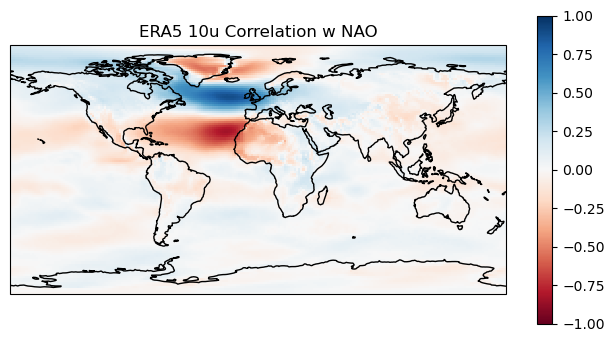

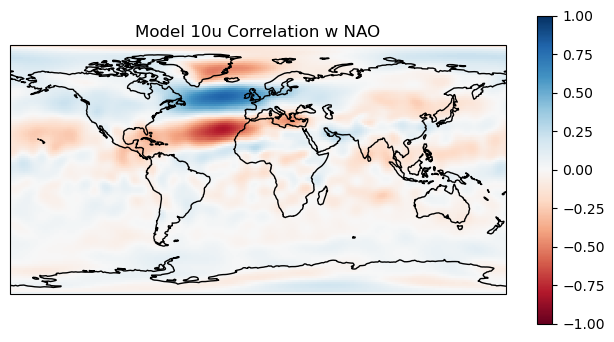

In [7]:
era5_var = era5_regridded.sel(varlev="VAR_10USFC", time=slice("1978-01-01", "2022-12-31"))


slp = era5_regridded.sel(varlev='SPSFC')
nao_index1 = calc_nao(slp)
da_dt, fit, gwm, p5  = global_detrend(era5_var, deg=2)
da_dt, monthly_clim = remove_climo(da_dt)

corr = xr.corr(nao_index1, da_dt, dim='time')
pl = corr.plot(subplot_kws={'projection': ccrs.PlateCarree()}, figsize = (8, 4), vmin=-1, vmax=1, cmap='RdBu')
pl.axes.coastlines() 
pl.axes.set_title('ERA5 10u Correlation w NAO')
plt.show() 

corrs = []
for m in range(1,6):
    model_var_0k = ds_0k.sel(varlev="VAR_10USFC", member=m).sel(time=slice("1978-01-01", "2022-12-31")).assign_coords({'time': era5_var.time})

    slp = ds_0k.sel(varlev='SPSFC', member=m).sel(time=slice("1978-01-01", "2022-12-31")).assign_coords({'time': era5_var.time})
    nao_index = calc_nao(slp)

    da_dt, fit, gwm, p5  = global_detrend(model_var_0k, deg=2)
    da_dt, monthly_clim = remove_climo(da_dt)

    corr = xr.corr(nao_index, da_dt, dim='time')
    corrs.append(corr)
corrs = xr.concat(corrs, 'member').mean('member') 
pl = corrs.plot(subplot_kws={'projection': ccrs.PlateCarree()}, figsize = (8, 4), vmin=-1, vmax=1, cmap='RdBu')
pl.axes.coastlines() 
pl.axes.set_title('Model 10u Correlation w NAO')
plt.show() 


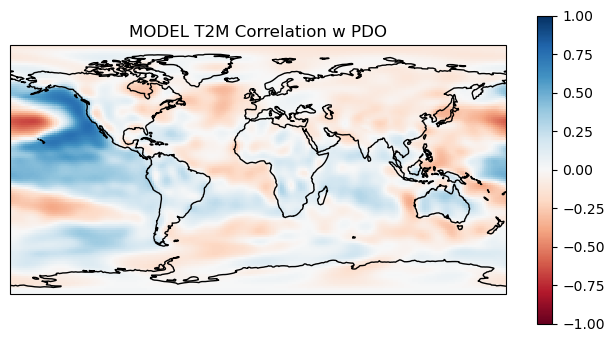

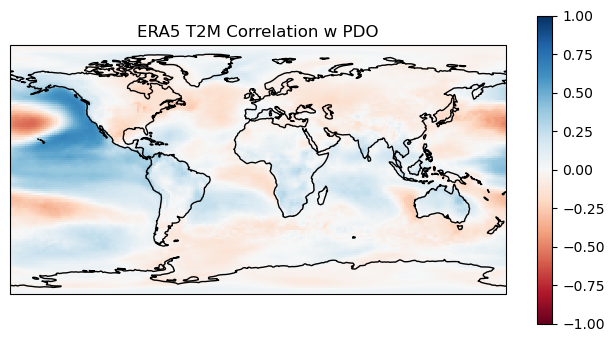

In [8]:
forcings = xr.open_dataset('/glade/work/khall/ERA5/AIMIP-Data/aimip-forcings-flat-1p5x1p5.nc').da.sel(time=model_var_0k.time.values)
pdo_index = calc_pdo(forcings.sel(varlev='SSTKSFC'))
model_var_0k = ds_0k.sel(varlev='VAR_2TSFC').mean('member').sel(time=slice("1978-01-01", "2022-12-31")).assign_coords({'time': era5_var.time})
era5_var = era5_regridded.sel(varlev='VAR_2TSFC')

titles = ['MODEL', 'ERA5']
for _, da in enumerate([model_var_0k, era5_var]):
    da_dt, fit, gwm, p5  = global_detrend(da, deg=2)
    da_dt, monthly_clim = remove_climo(da_dt)

    corr = xr.corr(pdo_index, da_dt, dim='time')

    pl = corr.plot(subplot_kws={'projection': ccrs.PlateCarree()}, figsize = (8, 4), vmin=-1, vmax=1, cmap='RdBu')
    pl.axes.coastlines() 
    pl.axes.set_title(f'{titles[_]} T2M Correlation w PDO')


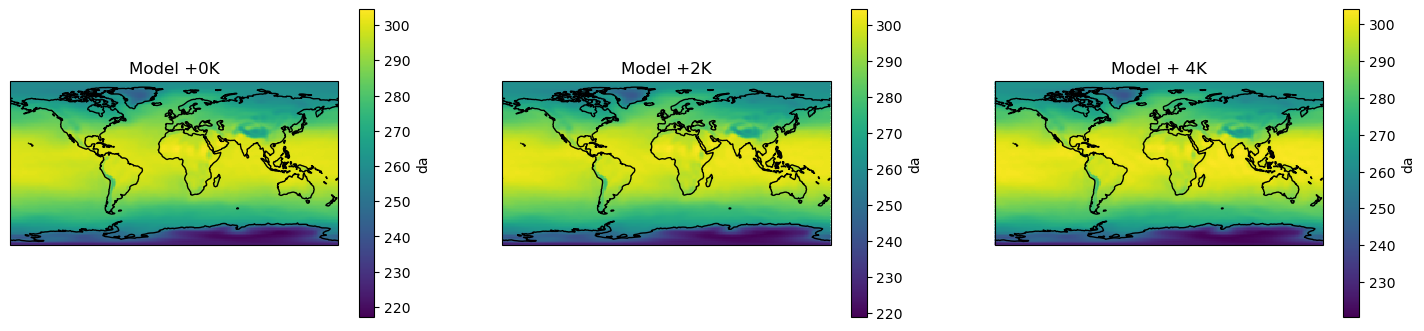

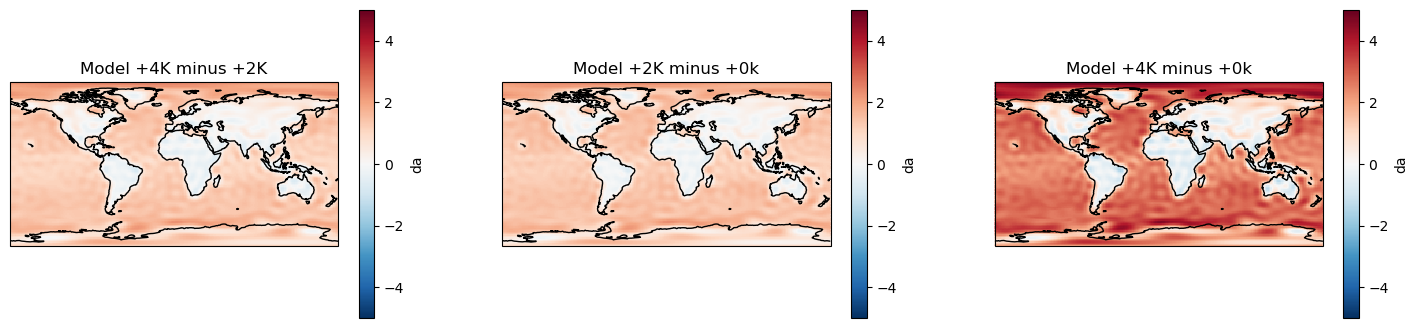

In [9]:
var = 'VAR_2TSFC'
ds_0k_regridded = ds_0k.sel(varlev=var).mean(['member', 'time'])
ds_2k_regridded =  ds_2k.sel(varlev=var).mean(['member', 'time'])
ds_4k_regridded =  ds_4k.sel(varlev=var).mean(['member', 'time'])

scale = 5

fig, axs = plt.subplots(nrows=1, ncols=3, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(18,4)) 
ds_0k_regridded.plot(ax=axs[0])
axs[0].set_title('Model +0K') 

ds_2k_regridded.plot(ax=axs[1]) 
axs[1].set_title('Model +2K') 

ds_4k_regridded.plot(ax=axs[2])
axs[2].set_title('Model + 4K') 

for ax in axs:
    ax.coastlines()
plt.show()


fig, axs = plt.subplots(nrows=1, ncols=3, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(18,4)) 
(ds_4k_regridded - ds_2k_regridded).plot(ax=axs[0], vmin=-scale, vmax=scale, cmap='RdBu_r')
axs[0].set_title('Model +4K minus +2K') 

(ds_2k_regridded - ds_0k_regridded).plot(ax=axs[1], vmin=-scale, vmax=scale, cmap='RdBu_r')
axs[1].set_title('Model +2K minus +0k') 

(ds_4k_regridded - ds_0k_regridded).plot(ax=axs[2], vmin=-scale, vmax=scale, cmap='RdBu_r')
axs[2].set_title('Model +4K minus +0k') 

for ax in axs:
    ax.coastlines()
plt.show()


In [ ]:
var = 'MTPRSFC'
ds_0k_regridded = ds_0k.sel(varlev=var).mean('member')
ds_2k_regridded =  ds_2k.sel(varlev=var).mean('member')
ds_4k_regridded =  ds_4k.sel(varlev=var).mean('member')

scale = 1e-5
fig, axs = plt.subplots(nrows=1, ncols=3, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(18,4)) 
ds_0k_regridded.mean('time').plot(ax=axs[0])
axs[0].set_title('Model +0K') 

ds_2k_regridded.mean('time').plot(ax=axs[1]) 
axs[1].set_title('Model +2K') 

ds_4k_regridded.mean('time').plot(ax=axs[2])
axs[2].set_title('Model + 4K') 

for ax in axs:
    ax.coastlines()
plt.show()


fig, axs = plt.subplots(nrows=1, ncols=3, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(18,4)) 
(ds_4k_regridded.mean('time') - ds_2k_regridded.mean('time')).plot(ax=axs[0], vmin=-scale, vmax=scale, cmap='BrBG')
axs[0].set_title('Model +4K minus +2K') 

(ds_2k_regridded.mean('time') - ds_0k_regridded.mean('time')).plot(ax=axs[1], vmin=-scale, vmax=scale, cmap='BrBG')
axs[1].set_title('Model +2K minus +0k') 

(ds_4k_regridded.mean('time') - ds_0k_regridded.mean('time')).plot(ax=axs[2], vmin=-scale, vmax=scale, cmap='BrBG')
axs[2].set_title('Model +4K minus +0k') 

for ax in axs:
    ax.coastlines()
plt.show()

In [ ]:

u_0k = ds_0k.sel(varlev=['u1000.0', 'u850.0', 'u700.0','u500.0', 'u250.0', 'u100.0', 'u50.0']).mean('member')
u_2k = ds_2k.sel(varlev=['u1000.0', 'u850.0', 'u700.0','u500.0', 'u250.0', 'u100.0', 'u50.0']).mean('member')
u_4k = ds_4k.sel(varlev=['u1000.0', 'u850.0', 'u700.0','u500.0', 'u250.0', 'u100.0', 'u50.0']).mean('member')
t_0k = ds_0k.sel(varlev=['t1000.0', 't850.0', 't700.0','t500.0', 't250.0', 't100.0', 't50.0']).mean('member')
t_2k = ds_2k.sel(varlev=['t1000.0', 't850.0', 't700.0','t500.0', 't250.0', 't100.0', 't50.0']).mean('member')
t_4k = ds_4k.sel(varlev=['t1000.0', 't850.0', 't700.0','t500.0', 't250.0', 't100.0', 't50.0']).mean('member')



In [ ]:
month = 1

runs = [0, 2, 4]
data = [[u_0k, u_2k, u_4k], [t_0k, t_2k, t_4k]]

fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
for _ in range(3):
    u_clim = data[0][_].groupby('time.month').mean().sel(month=month).mean('lon') 
    t_clim = data[1][_].groupby('time.month').mean().sel(month=month).mean('lon')

    pcm = axes[0, _].pcolormesh(
        u_clim.lat, u_clim.varlev, u_clim, 
        cmap='RdBu_r', vmin=-15, vmax=40
    )

    cs = axes[0, _].contour(
        t_clim.lat, t_clim.varlev, t_clim, 
        colors='k', linewidths=1
    )
    axes[0, _].clabel(cs, fmt='%2.1f', fontsize=8)
    axes[0, _].set_title(f"Model +{runs[_]}K Run")
    axes[0, _].set_xlabel('Latitude')
    axes[0, _].set_ylabel('Level (hPa)')
    axes[0, _].yaxis.set_inverted(True)

for _ in range(3):
    u_clim1 = data[0][_].groupby('time.month').mean().sel(month=month).mean('lon') 
    t_clim1 = data[1][_].groupby('time.month').mean().sel(month=month).mean('lon')

    u_clim2 = data[0][(_+1)%3].groupby('time.month').mean().sel(month=month).mean('lon') 
    t_clim2 = data[1][(_+1)%3].groupby('time.month').mean().sel(month=month).mean('lon')

    pcm = axes[1, _].pcolormesh(
        u_clim.lat, u_clim.varlev, u_clim2 - u_clim1 if _ < 2 else u_clim1 - u_clim2, 
        cmap='RdBu_r', vmin=-5, vmax=5
    )

    cs = axes[1, _].contour(
        t_clim.lat, t_clim.varlev, t_clim2 - t_clim1 if _ < 2 else t_clim1 - t_clim2, 
        colors='k', linewidths=1
    )
    axes[1, _].clabel(cs, fmt='%2.1f', fontsize=8)
    axes[1, _].set_title(f"Model +{runs[(_+1)%3]}K  minus Model +{runs[_]}K " if _ < 2 else f"Model +{runs[_]}K minus +{runs[(_+1)%3]}K ")
    axes[1, _].set_xlabel('Latitude')
    axes[1, _].set_ylabel('Level (hPa)')
    axes[1, _].yaxis.set_inverted(True)

plt.suptitle(f'Latitude-Height Cross Sections for {pd.Timestamp(f"1999-{month}-01").strftime("%B")}')
plt.tight_layout()


In [ ]:

runs = [0, 2, 4]
data = [[u_0k, u_2k, u_4k], [t_0k, t_2k, t_4k]]

fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
for _ in range(3):
    u_clim = data[0][_].mean('time').mean('lon') 
    t_clim = data[1][_].mean('time').mean('lon')

    pcm1 = axes[0, _].pcolormesh(
        u_clim.lat, u_clim.varlev, u_clim, 
        cmap='RdBu_r', vmin=-15, vmax=40
    )

    cs = axes[0, _].contour(
        t_clim.lat, t_clim.varlev, t_clim, 
        colors='k', linewidths=1
    )
    axes[0, _].clabel(cs, fmt='%2.1f', fontsize=8)
    axes[0, _].set_title(f"Model +{runs[_]}K Run")
    axes[0, _].set_xlabel('Latitude')
    axes[0, _].set_ylabel('Level (hPa)')
    axes[0, _].yaxis.set_inverted(True)

for _ in range(3):
    u_clim1 = data[0][_].mean('time').mean('lon') 
    t_clim1 = data[1][_].mean('time').mean('lon')

    u_clim2 = data[0][(_+1)%3].mean('time').mean('lon')
    t_clim2 = data[1][(_+1)%3].mean('time').mean('lon')

    pcm = axes[1, _].pcolormesh(
        u_clim.lat, u_clim.varlev, u_clim2 - u_clim1 if _ < 2 else u_clim1 - u_clim2, 
        cmap='RdBu_r', vmin=-5, vmax=5
    )

    cs = axes[1, _].contour(
        t_clim.lat, t_clim.varlev, t_clim2 - t_clim1 if _ < 2 else t_clim1 - t_clim2, 
        colors='k', linewidths=1
    )
    axes[1, _].clabel(cs, fmt='%2.1f', fontsize=8)
    axes[1, _].set_title(f"Model +{runs[(_+1)%3]}K  minus Model +{runs[_]}K " if _ < 2 else f"Model +{runs[_]}K minus +{runs[(_+1)%3]}K ")
    axes[1, _].set_xlabel('Latitude')
    axes[1, _].set_ylabel('Level (hPa)')
    axes[1, _].yaxis.set_inverted(True)

plt.suptitle(f'Latitude-Height Cross Sections Annual Mean')

from matplotlib.colors import TwoSlopeNorm
norm = TwoSlopeNorm(vmin=-15, vcenter=0, vmax=40)
cax = fig.add_axes([0.15, -0.04, 0.7, 0.03])

# Colorbar
cbar = fig.colorbar(pcm1, cax=cax, norm=norm, orientation='horizontal')
cbar.set_label("Zonal Wind (m/s)")


plt.tight_layout()
